In [13]:
# read the data 
# import the packages


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [14]:
file_path="C:\\DS_Py\\Visadataset.csv"
visa_df=pd.read_csv(file_path)
visa_df.head(5)

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,Denied
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,Certified
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,Denied
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,Denied
4,EZYV05,Africa,Master's,Y,N,1082,2005,South,149907.3900,Year,Y,Certified


$Box-plot$

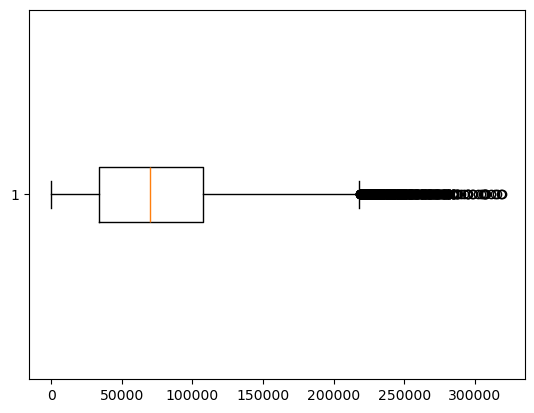

In [15]:
plt.boxplot(visa_df['prevailing_wage'],vert=False)
plt.show()

# black dots are nothing but a """ outlaiers"""

$Dealing$-$Outliers$
- Removal of outliers
- Impute the outliers with median value
  - because median is not impact by outliers
- cap the outliers with Q3, which are having more than Q3
- Cap the outliers with Q1, which are having less than Q1

**Find the outliers**

- Q3+1.5*IQR>    and    Q1-1.5*IQR
- step-1: calculate Q1 Q2 Q3
- step-2: Calculate IQR=(Q3-Q1)
- step-3: UB=Q3+1.5*IRQ
- step-4: LB=Q1-1.5IQR
- step-5: con1=col>UB
- step-6: con2=col<LB
- step-7: con1|con2
- step-8: col[con1|con2]

In [16]:
# finding outliers

# step-1: calculate Q1 Q2 Q3

q1=np.quantile(visa_df['prevailing_wage'],0.25)
q2=np.quantile(visa_df['prevailing_wage'],0.50)
q3=np.quantile(visa_df['prevailing_wage'],0.75)

# step-2: Calculate IQR=(Q3-Q1)
IQR=q3-q1

# step-3: UB=Q3+1.5*IRQ
UB=q3+1.5*IQR

# step-4: LB=Q1-1.5IQR
LB=q1-1.5*IQR

# step-5: con1=col>UB
con1=visa_df['prevailing_wage']>UB

# step-6: con2=col<LB
con2=visa_df['prevailing_wage']<LB

# step-7: con1|con2
con1|con2

# step-8: col[con1|con2]
outliers=visa_df['prevailing_wage'][con1|con2]

# converting series into array of values by applying a .values

outliers_data=outliers.values
len(outliers_data)

427

In [17]:
# these are only outliers
def outliers():
    q1=np.quantile(visa_df['prevailing_wage'],0.25)
    q2=np.quantile(visa_df['prevailing_wage'],0.50)
    q3=np.quantile(visa_df['prevailing_wage'],0.75)
    IQR=q3-q1
    UB=q3+1.5*IQR
    LB=q1-1.5*IQR
    con1=visa_df['prevailing_wage']>UB
    con2=visa_df['prevailing_wage']<LB
    con1|con2

    outliers=visa_df['prevailing_wage'][con1|con2]
    
    outliers_data=outliers.values
    return(outliers_data)


outlaiers_data=outliers()                   # calling a function
len(outliers_data)

427

In [18]:
# dataframe 

q1=np.quantile(visa_df['prevailing_wage'],0.25)
q2=np.quantile(visa_df['prevailing_wage'],0.50)
q3=np.quantile(visa_df['prevailing_wage'],0.75)
IQR=q3-q1
UB=q3+1.5*IQR
LB=q1-1.5*IQR
con1=visa_df['prevailing_wage']>UB
con2=visa_df['prevailing_wage']<LB
con1|con2

outliers_df=visa_df[con1|con2]         # outliers dataframe w.r.t p_wage  (427)
outliers_df

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
14,EZYV15,Asia,Master's,Y,Y,15756,2006,South,220081.73,Year,Y,Certified
34,EZYV35,Asia,Master's,N,N,1809,2010,South,225569.73,Year,N,Certified
130,EZYV131,South America,High School,N,N,2554,2005,Midwest,247393.01,Year,Y,Certified
216,EZYV217,Asia,Master's,Y,N,1515,2001,Midwest,269321.68,Year,N,Certified
221,EZYV222,North America,Doctorate,Y,Y,2518,2010,South,219529.62,Year,Y,Certified
...,...,...,...,...,...,...,...,...,...,...,...,...
25191,EZYV25192,Asia,Master's,N,N,4983,2005,Midwest,280482.51,Year,Y,Denied
25195,EZYV25196,North America,Master's,Y,N,47,2001,South,234308.77,Year,N,Certified
25468,EZYV25469,Asia,Bachelor's,N,N,373,2005,Midwest,272715.74,Year,N,Certified
25469,EZYV25470,North America,Master's,Y,N,2261,1997,Northeast,273772.47,Year,N,Certified


In [19]:
len(outliers_data),len(visa_df),len(outliers_data)*100/len(visa_df)

(427, 25480, 1.6758241758241759)

$case-1$

**Removal of outliers**

- we have 427 outliers in pre_wage column
- that means we need to remove 427 rows from entire dataframe

In [20]:
# in this small changes become ""non_outliers_dataset""

q1=np.quantile(visa_df['prevailing_wage'],0.25)
q2=np.quantile(visa_df['prevailing_wage'],0.50)
q3=np.quantile(visa_df['prevailing_wage'],0.75)
IQR=q3-q1
UB=q3+1.5*IQR
LB=q1-1.5*IQR
con1=visa_df['prevailing_wage']<UB         # change from >  to <
con2=visa_df['prevailing_wage']>LB         # change from < to >
con1|con2

non_outliers_df=visa_df[con1&con2]         # change from | to &
print(len(non_outliers_df))
non_outliers_df


# removed the outliers from the dataset

# now we will plot histogram plot

25053


,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,Denied
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,Certified
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,Denied
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,Denied
4,EZYV05,Africa,Master's,Y,N,1082,2005,South,149907.3900,Year,Y,Certified
...,...,...,...,...,...,...,...,...,...,...,...,...
25474,EZYV25475,Africa,Doctorate,N,N,2594,1979,Northeast,51104.7800,Year,Y,Certified
25475,EZYV25476,Asia,Bachelor's,Y,Y,2601,2008,South,77092.5700,Year,Y,Certified
25477,EZYV25478,Asia,Master's,Y,N,1121,1910,South,146298.8500,Year,N,Certified
25478,EZYV25479,Asia,Master's,Y,Y,1918,1887,West,86154.7700,Year,Y,Certified


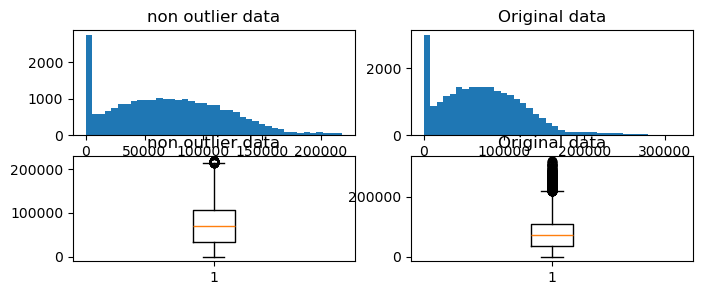

In [21]:
plt.figure(figsize=(8,3))
plt.subplot(2,2,1)
plt.title("non outlier data")
plt.hist(non_outliers_df['prevailing_wage'],bins=40)

plt.subplot(2,2,2)
plt.title("Original data")
plt.hist(visa_df['prevailing_wage'],bins=40)

plt.subplot(2,2,3)
plt.title("non outlier data")
plt.boxplot(non_outliers_df['prevailing_wage'])

plt.subplot(2,2,4)
plt.title("Original data")
plt.boxplot(visa_df['prevailing_wage'])
plt.show()

$case - 2$

**Impute with median**
- we got pre_wage has 427 outliers
- we replace those 427 with median value of pre_wage

In [22]:
UB,LB

(np.float64(218315.56125000003), np.float64(-76564.56875000002))

In [32]:
q1=np.quantile(visa_df['prevailing_wage'],0.25)
q2=np.quantile(visa_df['prevailing_wage'],0.50)
q3=np.quantile(visa_df['prevailing_wage'],0.75)
IQR=q3-q1
UB=q3+1.5*IQR
LB=q1-1.5*IQR
con1=visa_df['prevailing_wage']>UB
con2=visa_df['prevailing_wage']<LB
con1|con2

outliers=visa_df['prevailing_wage'][con1|con2]         # outliers dataframe w.r.t p_wage  (427)
len(outliers)

427

In [125]:
# iterate through pre_wages as i                                                                    # 52 nd class
# if a value>ub or <lb ====> median
# else: i

# if condition:
#      append median
# else:
#     append i

new_data=[]
for i in visa_df['prevailing_wage']:
    if i>UB or i<LB:
        new_data.append(visa_df['prevailing_wage'].median())
    else:
        new_data.append(i)
len(new_data)


# we are iterating through pre_wage data
# if any datapoints > UB or < LB means it is a outliers so in that position
#              we are keeping median value of the column

# otherwise keeping the same value

25480

$np.where$

In [88]:
# using np.where we can create above list 

dict1={'Col1':[1,2,3,4],
       'Col2':['A','B','C','D']}
data=pd.DataFrame(dict1)
data

# impute with a value 100 in the col1
# which are having values >2
#    output
# col1   col2
#   1      A
#   2      B
#   100    c
#   100    D

,Col1,Col2
0,1,A
1,2,B
2,3,C
3,4,D


- np.where will take 3 arguments values
- condition: con=data['Col1']>2
- If that condition is True will provide the value:100
- If that condition is False will keep the same value: data['Col1']
- np.where(<condition>,<True_value>,<False_value>)

In [101]:
con=data['Col1']>2
np.where(con,100,data['Col1'])

# np.where is only for binary conditions, 
# True False
# if - else

array([  1,   2, 100, 100])

In [102]:
data

,Col1,Col2
0,1,A
1,2,B
2,3,C
3,4,D


$case-1$

**create a new column**

In [114]:
data['new_col']=[100,200,300,400]
data

,Col1,Col2,new_col
0,1,A,100
1,2,B,200
2,100,C,300
3,100,D,400


In [115]:
con=data['Col1']>2
data['Col3']=np.where(con,100,data['Col1'])
data


,Col1,Col2,new_col,Col3
0,1,A,100,1
1,2,B,200,2
2,100,C,300,100
3,100,D,400,100


$Case-2$

**Overwrite the column values**

In [116]:
# col3 write as col1
con=data['Col1']>2
data['Col1']=np.where(con,100,data['Col1'])
data

,Col1,Col2,new_col,Col3
0,1,A,100,1
1,2,B,200,2
2,100,C,300,100
3,100,D,400,100


In [117]:
# Drop unwanted columns
data.drop(['new_col','Col3'],axis=1,inplace=True)
data

,Col1,Col2
0,1,A
1,2,B
2,100,C
3,100,D


In [118]:
data

,Col1,Col2
0,1,A
1,2,B
2,100,C
3,100,D


$Task$

**Implement the same thing for prevailing wage**

In [121]:
con1=visa_df['prevailing_wage']>UB
con2=visa_df['prevailing_wage']<LB
con=con1|con2
median=visa_df['prevailing_wage'].median()
visa_df['prevailing_wage']=np.where(con,median,visa_df['prevailing_wage'])

{'whiskers': [<matplotlib.lines.Line2D at 0x289ec4c6990>,
 'caps': [<matplotlib.lines.Line2D at 0x289ec9d16d0>,
 'boxes': [<matplotlib.lines.Line2D at 0x289ec4c6850>],
 'medians': [<matplotlib.lines.Line2D at 0x289ec9d0050>],
 'fliers': [<matplotlib.lines.Line2D at 0x289ec9d0690>],
 'means': []}

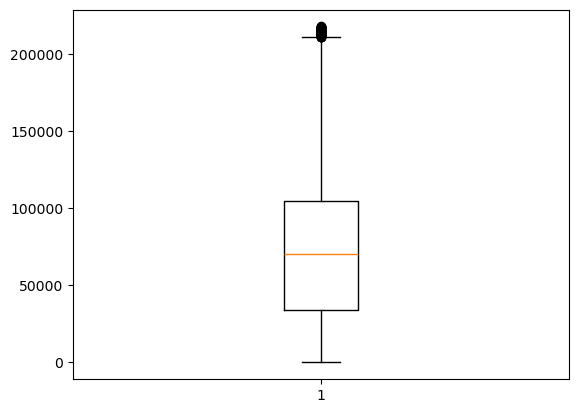

In [122]:
plt.boxplot(visa_df['prevailing_wage'])